# NYC Restaurant Inspections Data Analysis
---
## Research Question
How does restaurant health inspection risk vary across neighborhoods in New York City, and what does that variation suggest about the relationship between neighborhood conditions and food safety outcomes?

## Datasets
[New York City Restaurant Inspection Results](https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data)

[New York City Rodent Inspections](https://data.cityofnewyork.us/Health/Rodent-Inspection/p937-wjvj/about_data)

[New York City Income Dataset](https://data.cccnewyork.org/data/map/66/median-incomes)

[New York City 311 Complaint Dataset](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9/about_data)

---

## Table of Contents

1.   Setup
2.   Data Loading
3.   Restaurant Inspection Data Analysis (Cleaning, Exploration, Visualization)
4.   Rodent Inspection Data Analysis (Cleaning, Exploration, Visualization)
5.   Income Data Analysis (Cleaning, Exploration, Visualization)
6.   311 Complaint Data Analysis (Cleaning, Exploration, Visualization)
---


## Setup

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO

---

## Data Loading

In [49]:
base_url = "https://data.cityofnewyork.us/resource/43nn-pn8j.csv"

params = {
    "$select": "camis,dba,boro,zipcode,cuisine_description,inspection_date,critical_flag,score,grade,latitude,longitude",
    "$where": "boro='Queens' AND inspection_date>'2023-01-01T00:00:00'",
    "$limit": 300000
}

response = requests.get(base_url, params=params)
inspections_df = pd.read_csv(StringIO(response.text))

In [50]:
base_url = "https://data.cityofnewyork.us/resource/p937-wjvj.csv"

params = {
    "$select": "inspection_type,zip_code,borough,inspection_date,result,latitude,longitude",
    "$where": "borough='Queens' AND inspection_date>'2023-01-01T00:00:00'",
    "$limit": 300000
}

response = requests.get(base_url, params=params)
rodents_df = pd.read_csv(StringIO(response.text))

In [51]:
income_df = pd.read_csv("data/median_income.csv")

In [52]:
base_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"

params = {
    "$select": "created_date,agency,complaint_type,descriptor,incident_zip,borough,latitude,longitude",
    "$where": "borough='QUEENS' AND created_date>'2023-01-01T00:00:00'",
    "$limit": 3000000
}

response = requests.get(base_url, params=params)
complaints_df = pd.read_csv(StringIO(response.text))

In [53]:
# Data Visualization Setup
sns.set_theme(style="whitegrid")
inspection_colors = sns.color_palette("Purples_d")
rodent_colors = sns.color_palette("Reds")
complaints_colors = sns.color_palette("Oranges_d")

---

## Restaraunt Inspection Data Analysis (Cleaning, Exploration, Visualization)

In [54]:
inspections_df.shape

(68891, 11)

In [55]:
inspections_df.columns

Index(['camis', 'dba', 'boro', 'zipcode', 'cuisine_description',
       'inspection_date', 'critical_flag', 'score', 'grade', 'latitude',
       'longitude'],
      dtype='str')

In [56]:
inspections_df.head()

,camis,dba,boro,zipcode,cuisine_description,inspection_date,critical_flag,score,grade,latitude,longitude
0,50086669,BALANCERO,Queens,11103.0,Coffee/Tea,2024-09-17T00:00:00.000,Critical,27.0,NaN,40.762689,-73.918164
1,41395342,"CITI FIELD - MISTER SOFTEE, STAND 131",Queens,NaN,Frozen Desserts,2025-09-13T00:00:00.000,Not Applicable,0.0,A,0.000000,0.000000
2,41131002,TANGRA,Queens,NaN,Asian/Asian Fusion,2023-01-04T00:00:00.000,Not Critical,13.0,A,0.000000,0.000000
3,41657465,NAN BEI HO,Queens,11364.0,Chinese,2024-06-07T00:00:00.000,Critical,48.0,NaN,40.755357,-73.768640
4,50057589,TOUS LES JOURS,Queens,11354.0,Bakery Products/Desserts,2026-06-16T00:00:00.000,Critical,22.0,B,40.759478,-73.832243


In [57]:
inspections_df.isna().sum()

camis                      0
dba                        0
boro                       0
zipcode                  525
cuisine_description        0
inspection_date            0
critical_flag              0
score                   3493
grade                  35661
latitude                 415
longitude                415
dtype: int64

In [58]:
inspections_df['cuisine_description'].value_counts()

cuisine_description
Chinese                      9709
American                     7035
Latin American               6661
Bakery Products/Desserts     3697
Caribbean                    3441
                             ... 
Not Listed/Not Applicable       5
Ethiopian                       4
Chimichurri                     4
Southwestern                    2
Californian                     1
Name: count, Length: 81, dtype: int64

In [59]:
inspections_df['critical_flag'].value_counts()

critical_flag
Critical          36954
Not Critical      30989
Not Applicable      948
Name: count, dtype: int64

In [60]:
inspections_df['grade'].value_counts()

grade
A    20838
B     4780
C     3752
N     2164
Z     1497
P      199
Name: count, dtype: int64

### Key Metrics:

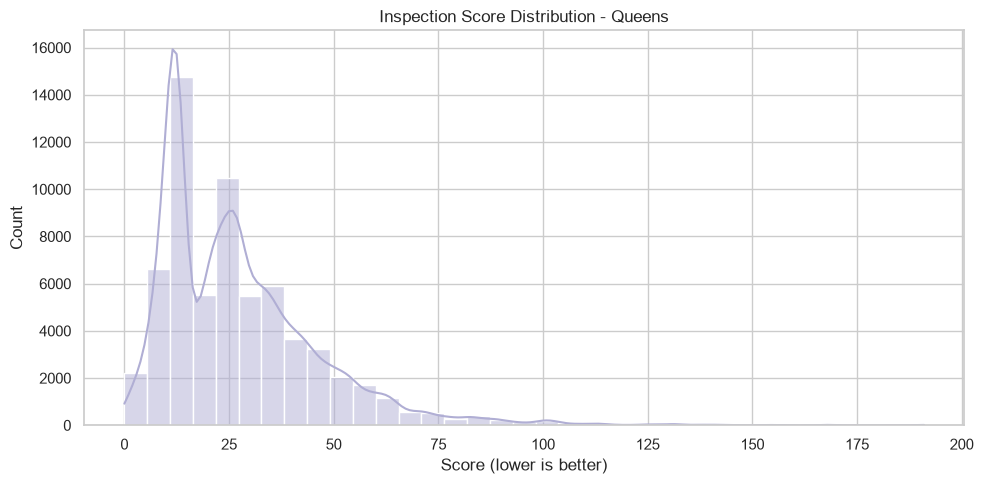

In [61]:
# Inspection Score Distribution - Queens
plt.figure(figsize=(10, 5))
sns.histplot(inspections_df['score'].dropna(), bins=35, color=inspection_colors[0], kde=True)
plt.title('Inspection Score Distribution - Queens')
plt.xlabel('Score (lower is better)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_55028\4091679148.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_counts.index, y=grade_counts.values, palette=inspection_colors)


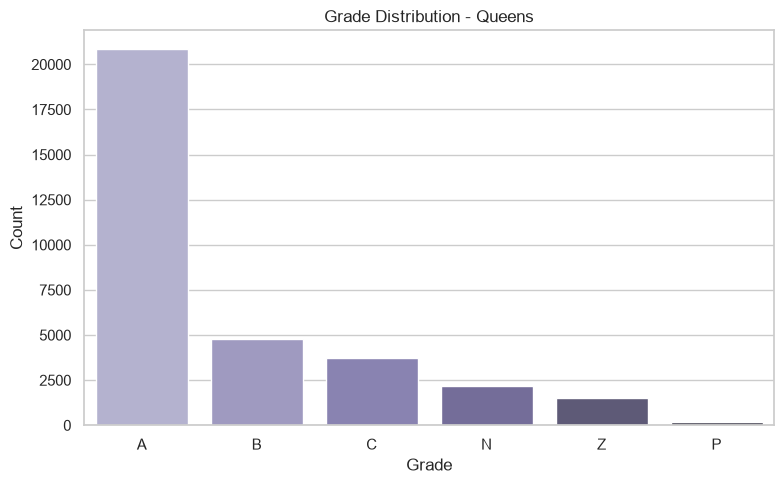

In [62]:
# Grade Distribution - Queens
grade_counts = inspections_df['grade'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette=inspection_colors)
plt.title('Grade Distribution - Queens')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

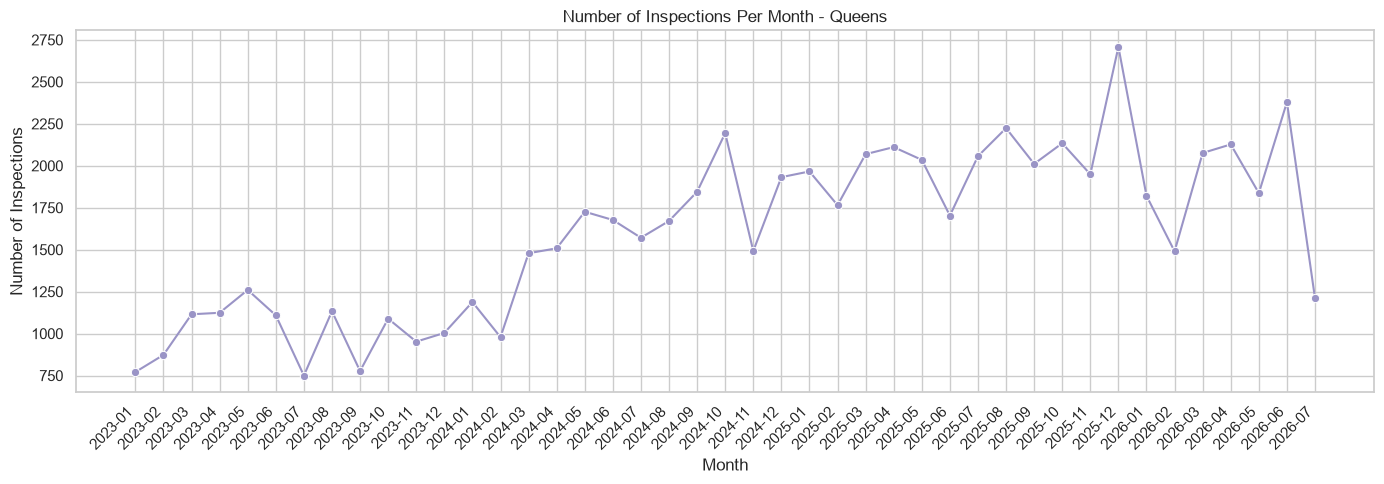

In [63]:
# Number of Inspections Per Year - Queens
inspections_df['month'] = pd.to_datetime(inspections_df['inspection_date']).dt.to_period('M')
month_counts = inspections_df['month'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.lineplot(x=month_counts.index.astype(str), y=month_counts.values, marker='o', color=inspection_colors[1])
plt.title('Number of Inspections Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_55028\1986180202.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="Purples_d")


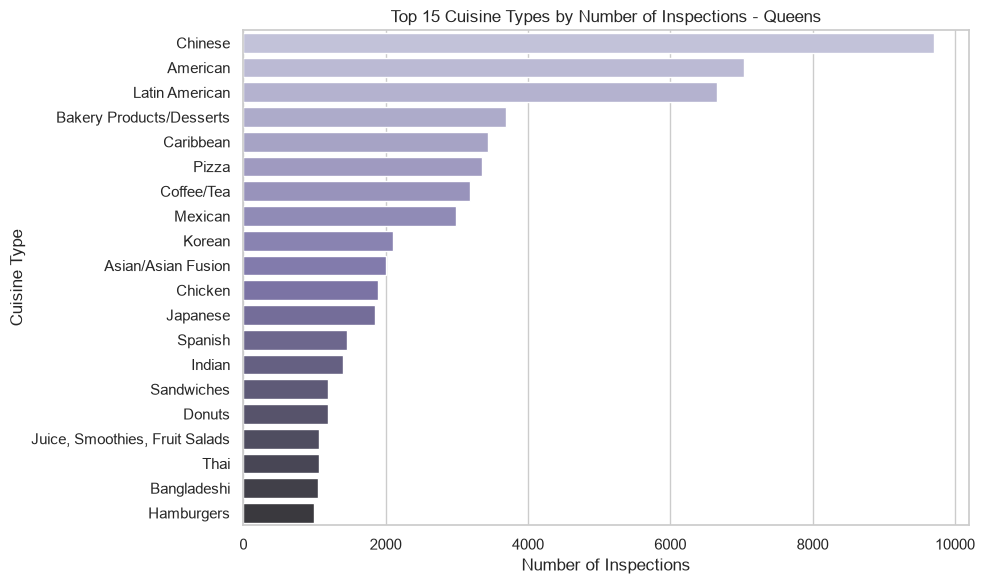

In [64]:
# Top 20 Cuisine Types by Number of Inspections - Queens
top_cuisines = inspections_df['cuisine_description'].value_counts().head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette="Purples_d")
plt.title('Top 15 Cuisine Types by Number of Inspections - Queens')
plt.xlabel('Number of Inspections')
plt.ylabel('Cuisine Type')
plt.tight_layout()
plt.show()

---

## Rodent Inspection Data Analysis (Cleaning, Exploration, Visualization)

In [65]:
rodents_df.shape

(49781, 7)

In [66]:
rodents_df.columns

Index(['inspection_type', 'zip_code', 'borough', 'inspection_date', 'result',
       'latitude', 'longitude'],
      dtype='str')

In [67]:
rodents_df.head()

,inspection_type,zip_code,borough,inspection_date,result,latitude,longitude
0,Treatments,11433.0,Queens,2026-04-21T11:40:36.000,Bait applied,40.705653,-73.792109
1,Initial,11691.0,Queens,2026-02-27T10:30:57.000,Passed,40.606437,-73.752314
2,Initial,11434.0,Queens,2026-01-15T13:16:31.000,Passed,40.663249,-73.769217
3,Compliance,11434.0,Queens,2026-01-15T10:56:21.000,Passed,40.666955,-73.771003
4,Initial,11414.0,Queens,2023-05-24T15:00:04.000,Passed,40.654139,-73.830804


In [68]:
rodents_df.isna().sum()

inspection_type      0
zip_code           216
borough              0
inspection_date      0
result               0
latitude           187
longitude          187
dtype: int64

In [69]:
rodents_df['inspection_type'].value_counts()

inspection_type
Initial       27974
Compliance    11891
Treatments     9742
Clean Ups       130
Stoppage         44
Name: count, dtype: int64

In [70]:
rodents_df['result'].value_counts()

result
Passed                                      21490
Failed for Rat Activity                      9151
Bait applied                                 9006
Failed for Other Reason                      5306
Failed for Rat Activity and Other Reason     3918
Monitoring visit                              736
Cleanup done                                  130
Stoppage done                                  44
Name: count, dtype: int64

### Key Metrics:

C:\Users\chena\AppData\Local\Temp\ipykernel_55028\2695707273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=result_counts.values, y=result_counts.index, palette=rodent_colors)
C:\Users\chena\AppData\Local\Temp\ipykernel_55028\2695707273.py:4: UserWarning: 
The palette list has fewer values (6) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=result_counts.values, y=result_counts.index, palette=rodent_colors)


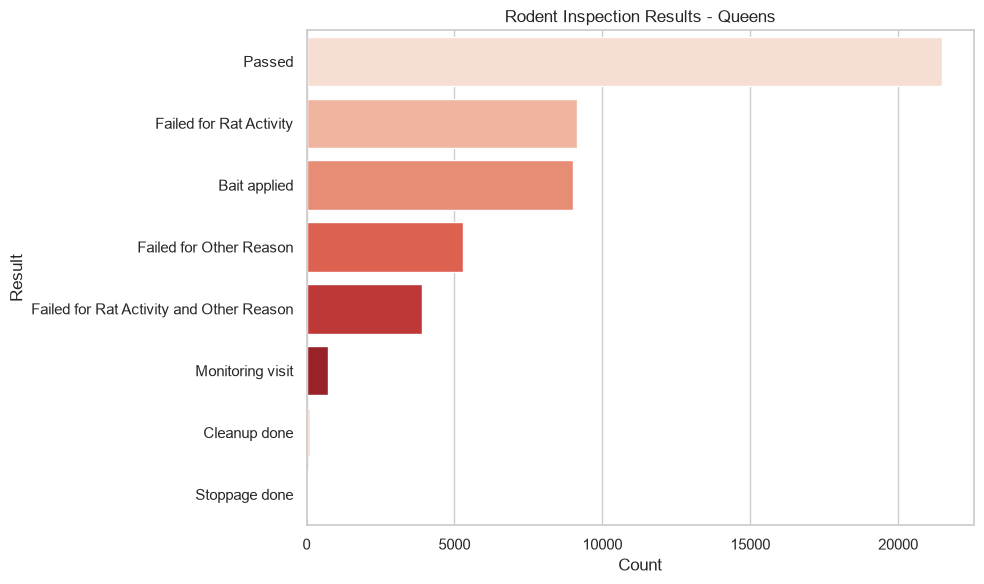

In [71]:
result_counts = rodents_df['result'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=result_counts.values, y=result_counts.index, palette=rodent_colors)
plt.title('Rodent Inspection Results - Queens')
plt.xlabel('Count')
plt.ylabel('Result')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_55028\3472836620.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.values, y=type_counts.index, palette=rodent_colors)
C:\Users\chena\AppData\Local\Temp\ipykernel_55028\3472836620.py:4: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.barplot(x=type_counts.values, y=type_counts.index, palette=rodent_colors)


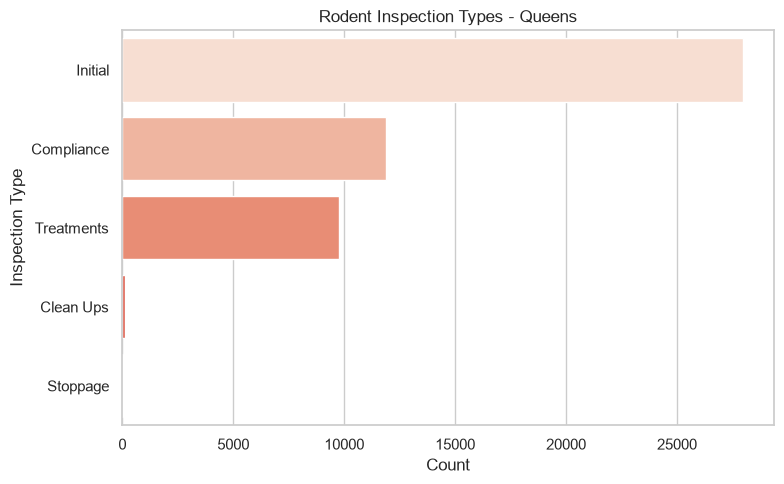

In [72]:
type_counts = rodents_df['inspection_type'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=type_counts.values, y=type_counts.index, palette=rodent_colors)
plt.title('Rodent Inspection Types - Queens')
plt.xlabel('Count')
plt.ylabel('Inspection Type')
plt.tight_layout()
plt.show()

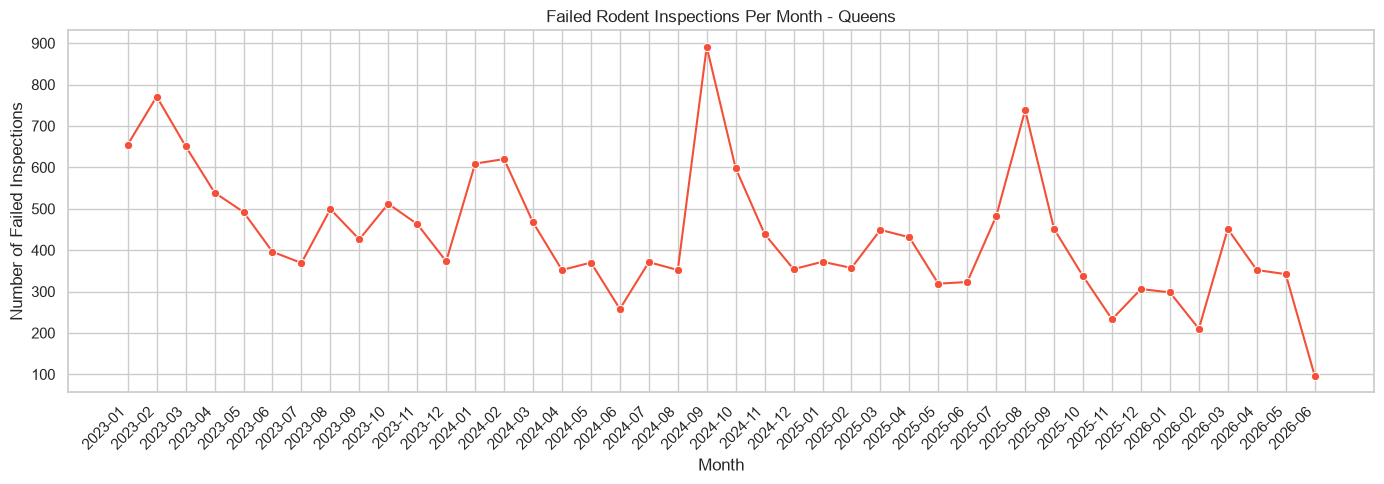

In [73]:
rodents_df['month'] = pd.to_datetime(rodents_df['inspection_date']).dt.to_period('M')

failed_df = rodents_df[rodents_df['result'].str.contains('Failed', na=False)]
failed_monthly = failed_df['month'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.lineplot(x=failed_monthly.index.astype(str), y=failed_monthly.values, marker='o', color=rodent_colors[3])
plt.title('Failed Rodent Inspections Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Failed Inspections')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

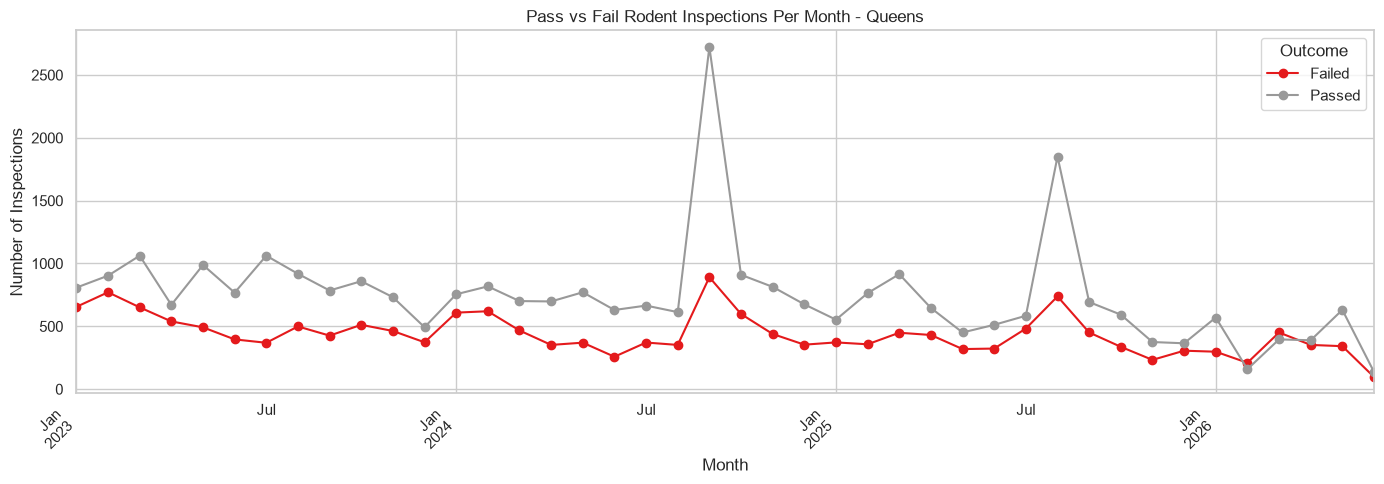

In [74]:
rodents_df['outcome'] = rodents_df['result'].apply(
    lambda x: 'Failed' if 'Failed' in str(x) else 'Passed'
)

outcome_monthly = rodents_df.groupby(['month', 'outcome']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 5))
outcome_monthly.plot(kind='line', marker='o', colormap='Set1', ax=plt.gca())
plt.title('Pass vs Fail Rodent Inspections Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Inspections')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Outcome')
plt.tight_layout()

plt.show()

---

## Income Data Analysis (Cleaning, Exploration, Visualization)

In [106]:
income_df.shape

(4934, 6)

In [107]:
income_df.columns

Index(['Location', 'Household Type', 'TimeFrame', 'DataFormat', 'Data',
       'Fips'],
      dtype='str')

In [108]:
income_df.head(20)

,Location,Household Type,TimeFrame,DataFormat,Data,Fips
0,Chelsea/Clinton,Families with Children,2022,Dollars,#VALUE!,104
1,Chelsea/Clinton,Families without Children,2022,Dollars,#VALUE!,104
2,Chelsea/Clinton,Families with Children,2023,Dollars,148390.7556,104
3,Manhattanville,Families with Children,2023,Dollars,49241.12379,109
4,Central Harlem,Families with Children,2023,Dollars,76479.32647,110
5,Bushwick,Families with Children,2023,Dollars,54303.07229,304
6,The Rockaways,Families with Children,2023,Dollars,61773.00121,414
7,Riverdale,All Households,2005,Dollars,75953.59121,208
8,Williamsbridge,All Households,2005,Dollars,62431.24681,212
9,Throgs Neck,All Households,2005,Dollars,69101.28539,210


In [105]:
income_df = pd.read_csv("data/median_income.csv")

In [109]:
income_df = income_df[((income_df["Fips"] >= 401) & (income_df["Fips"] <= 414)) | (income_df["Fips"] == 36081)]

In [ ]:
# income_df = income_df[income_df["TimeFrame"] >= 2023]

In [110]:
income_df = income_df.rename(columns={"Data": "Median Income"})

In [111]:
income_df["Median Income"] = pd.to_numeric(income_df["Median Income"])

In [112]:
income_df = income_df.drop(columns=["DataFormat","Fips"])

In [113]:
income_df.head()

,Location,Household Type,TimeFrame,Median Income
6,The Rockaways,Families with Children,2023,61773.00121
52,Astoria,All Households,2005,59207.00202
53,Jackson Heights,All Households,2005,64656.16427
54,Flushing,All Households,2005,77220.03434
55,Bayside,All Households,2005,103992.89354


In [114]:
income_df.columns

Index(['Location', 'Household Type', 'TimeFrame', 'Median Income'], dtype='str')

In [115]:
income_df['Household Type'].value_counts()

Household Type
All Households               285
Families                     285
Families without Children    285
Families with Children       284
Name: count, dtype: int64

In [116]:
income_df['Location'].value_counts().head(20)

Location
The Rockaways              76
Astoria                    76
Jackson Heights            76
Flushing                   76
Bayside                    76
Queens Village             76
Fresh Meadows/Briarwood    76
Elmhurst/Corona            76
Rego Park/Forest Hills     76
Ridgewood/Glendale         76
Woodhaven                  76
Jamaica/St. Albans         76
Howard Beach               76
Queens                     76
Sunnyside/Woodside         75
Name: count, dtype: int64

C:\Users\chena\AppData\Local\Temp\ipykernel_55028\2949479117.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Median Income', y='Location', data=recent, palette='Blues_d')


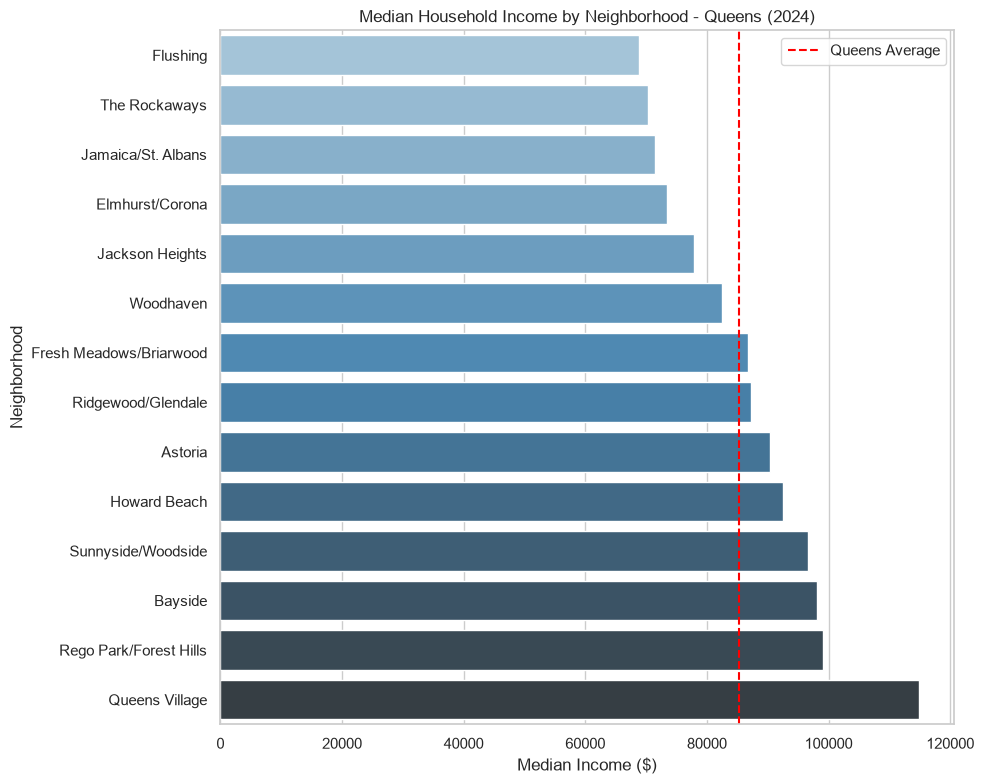

In [123]:
# exclude borough-wide average and filter to All Households for clarity
recent = income_df[
    (income_df['TimeFrame'] == 2024) & 
    (income_df['Household Type'] == 'All Households') &
    (income_df['Location'] != 'Queens')
].sort_values('Median Income')

plt.figure(figsize=(10, 8))
sns.barplot(x='Median Income', y='Location', data=recent, palette='Blues_d')
plt.axvline(x=income_df[(income_df['TimeFrame'] == 2024) & (income_df['Location'] == 'Queens') & (income_df['Household Type'] == 'All Households')]['Median Income'].values[0], color='red', linestyle='--', label='Queens Average')
plt.title('Median Household Income by Neighborhood - Queens (2024)')
plt.xlabel('Median Income ($)')
plt.ylabel('Neighborhood')
plt.legend()
plt.tight_layout()
plt.show()

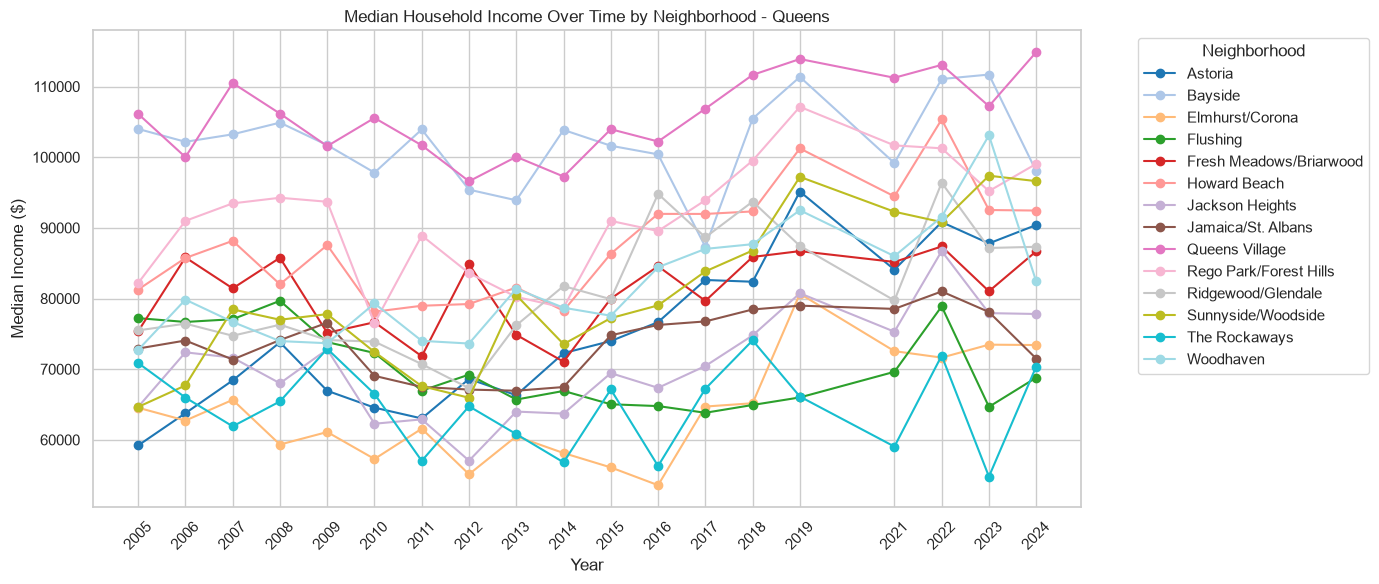

In [119]:
all_households = income_df[
    (income_df['Household Type'] == 'All Households') &
    (income_df['Location'] != 'Queens')
].pivot(index='TimeFrame', columns='Location', values='Median Income')

plt.figure(figsize=(14, 6))
all_households.plot(kind='line', marker='o', colormap='tab20', ax=plt.gca())
plt.title('Median Household Income Over Time by Neighborhood - Queens')
plt.xlabel('Year')
plt.ylabel('Median Income ($)')
plt.legend(title='Neighborhood', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(all_households.index, all_households.index.astype(int), rotation=45)
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_55028\2088012333.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Median Income', y='Household Type', data=household_2024, palette='Blues_d')


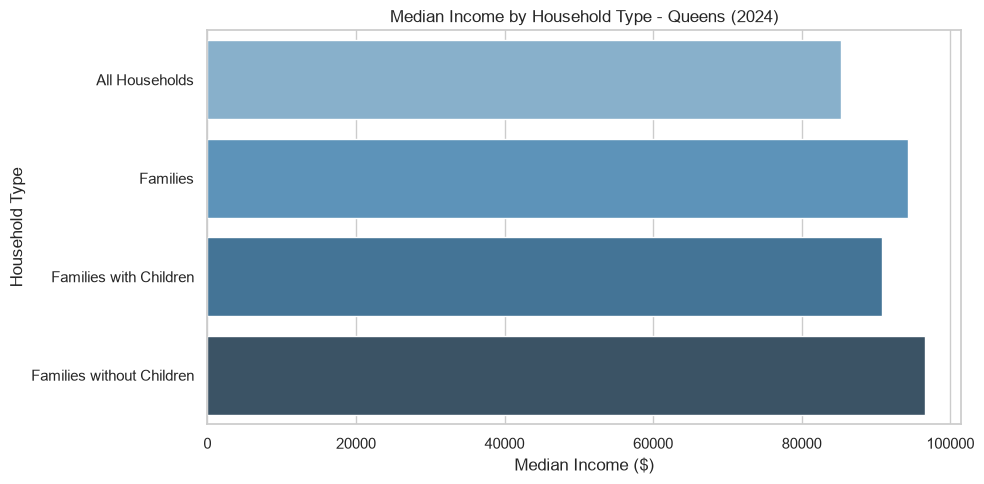

In [124]:
household_2024 = income_df[
    (income_df['TimeFrame'] == 2024) &
    (income_df['Location'] == 'Queens')
]

plt.figure(figsize=(10, 5))
sns.barplot(x='Median Income', y='Household Type', data=household_2024, palette='Blues_d')
plt.title('Median Income by Household Type - Queens (2024)')
plt.xlabel('Median Income ($)')
plt.ylabel('Household Type')
plt.tight_layout()
plt.show()

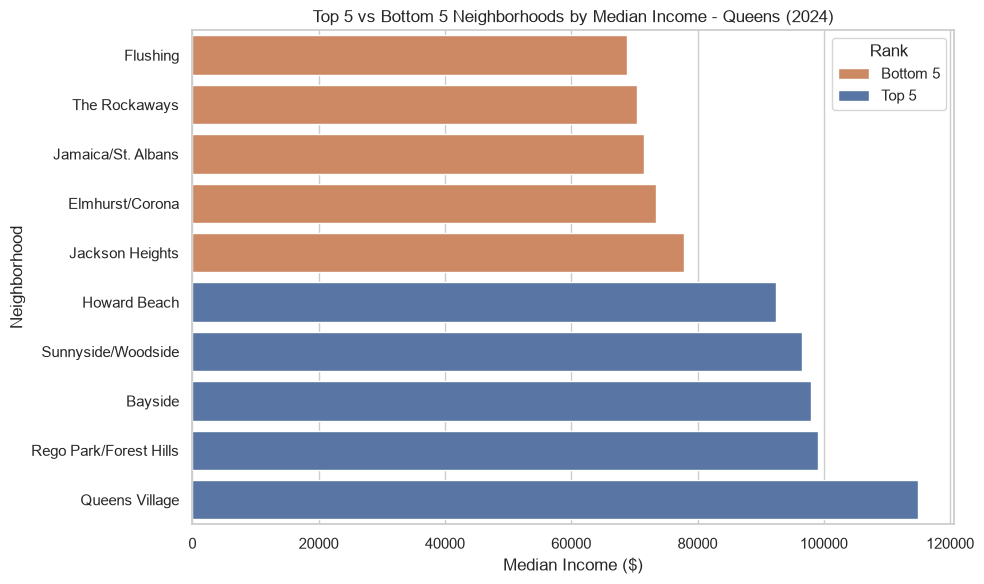

In [121]:
recent_sorted = income_df[
    (income_df['TimeFrame'] == 2024) &
    (income_df['Household Type'] == 'All Households') &
    (income_df['Location'] != 'Queens')
].sort_values('Median Income')

top_bottom = pd.concat([recent_sorted.head(5), recent_sorted.tail(5)])
top_bottom['Rank'] = ['Bottom 5'] * 5 + ['Top 5'] * 5

plt.figure(figsize=(10, 6))
sns.barplot(x='Median Income', y='Location', hue='Rank', data=top_bottom, palette={'Top 5': '#4C72B0', 'Bottom 5': '#DD8452'})
plt.title('Top 5 vs Bottom 5 Neighborhoods by Median Income - Queens (2024)')
plt.xlabel('Median Income ($)')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

---

## 311 Complaints Data Analysis (Cleaning, Exploration, Visualization)

In [93]:
complaints_df.shape

(3000000, 8)

In [94]:
complaints_df.columns

Index(['created_date', 'agency', 'complaint_type', 'descriptor',
       'incident_zip', 'borough', 'latitude', 'longitude'],
      dtype='str')

In [95]:
complaints_df.head()

,created_date,agency,complaint_type,descriptor,incident_zip,borough,latitude,longitude
0,2026-07-19T02:05:42.000,NYPD,Noise - Vehicle,Car/Truck Music,11385.0,QUEENS,40.698413,-73.893912
1,2026-07-19T02:04:59.000,NYPD,Illegal Parking,Blocked Hydrant,11372.0,QUEENS,40.747560,-73.887694
2,2026-07-19T02:03:07.000,NYPD,Illegal Parking,Blocked Hydrant,11372.0,QUEENS,40.749127,-73.887049
3,2026-07-19T02:03:01.000,NYPD,Noise - Residential,Loud Music/Party,11368.0,QUEENS,40.740996,-73.865627
4,2026-07-19T02:01:51.000,NYPD,Illegal Parking,Blocked Hydrant,11372.0,QUEENS,40.749102,-73.887046


In [96]:
complaints_df.isna().sum()

created_date          0
agency                0
complaint_type        0
descriptor        44738
incident_zip      31599
borough               0
latitude          76022
longitude         76022
dtype: int64

In [97]:
complaints_df['agency'].value_counts()

agency
NYPD          1534877
HPD            342333
DSNY           295663
DOT            251349
DEP            180967
DPR            147444
DOB             95662
DOHMH           60858
EDC             26891
TLC             26085
DHS             19016
DCWP            16394
DOE              1468
OOS               767
OTI               121
NYC311-PRD        104
3-1-1               1
Name: count, dtype: int64

In [98]:
complaints_df['complaint_type'].value_counts().head(20)

complaint_type
Illegal Parking             574370
Blocked Driveway            258127
Noise - Residential         257121
HEAT/HOT WATER              133705
Street Condition            108487
Abandoned Vehicle           100929
Noise - Street/Sidewalk      92419
Water System                 65344
UNSANITARY CONDITION         58884
Drug Activity                58069
Derelict Vehicles            54629
Noise - Commercial           47954
Noise - Vehicle              47352
Dirty Condition              47131
Traffic Signal Condition     46554
Missed Collection            45685
Damaged Tree                 44686
Sewer                        41174
Illegal Dumping              38392
Noise                        37509
Name: count, dtype: int64

In [99]:
complaints_df['descriptor'].value_counts()

descriptor
Loud Music/Party                 271416
No Access                        185133
Blocked Hydrant                  179837
Posted Parking Sign Violation    114367
With License Plate               100929
                                  ...  
Electronic Sign - Portable            1
Dirt, Litter, Debris - Garage         1
Supervisory                           1
User Unlicensed                       1
Debris                                1
Name: count, Length: 1033, dtype: int64

### Key Metrics

C:\Users\chena\AppData\Local\Temp\ipykernel_55028\4250082746.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_complaints.values, y=top_complaints.index, palette="Oranges_d")


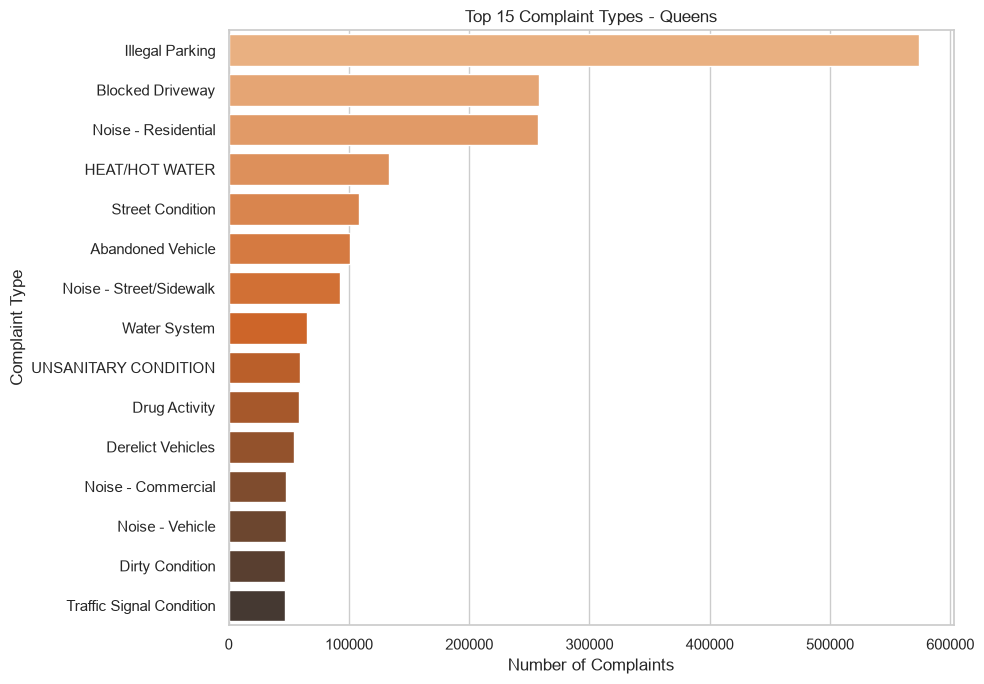

In [100]:
top_complaints = complaints_df['complaint_type'].value_counts().head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_complaints.values, y=top_complaints.index, palette="Oranges_d")
plt.title('Top 15 Complaint Types - Queens')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')
plt.tight_layout()
plt.show()

C:\Users\chena\AppData\Local\Temp\ipykernel_55028\939093494.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agency_counts.values, y=agency_counts.index, palette="Oranges_d")


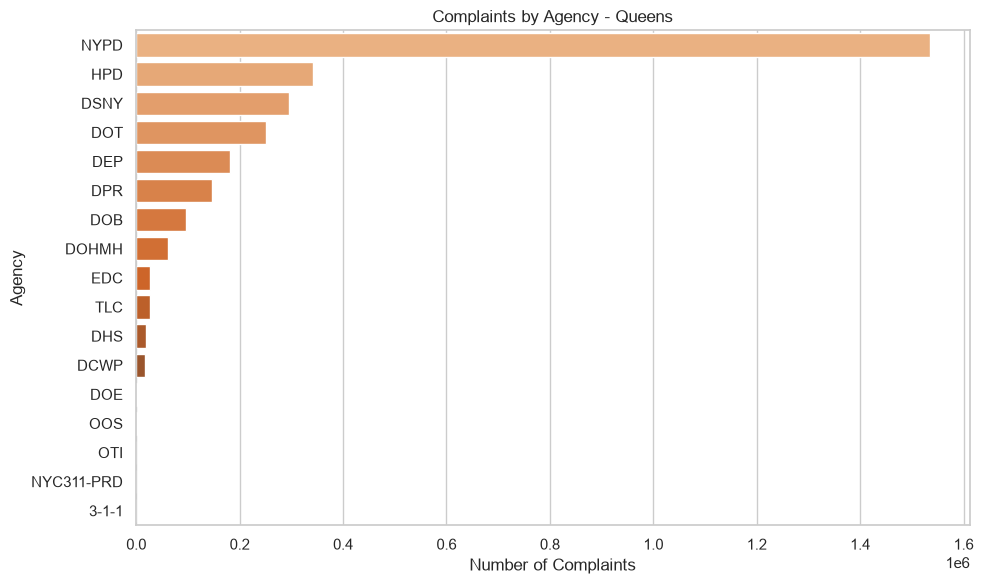

In [101]:
agency_counts = complaints_df['agency'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=agency_counts.values, y=agency_counts.index, palette="Oranges_d")
plt.title('Complaints by Agency - Queens')
plt.xlabel('Number of Complaints')
plt.ylabel('Agency')
plt.tight_layout()
plt.show()

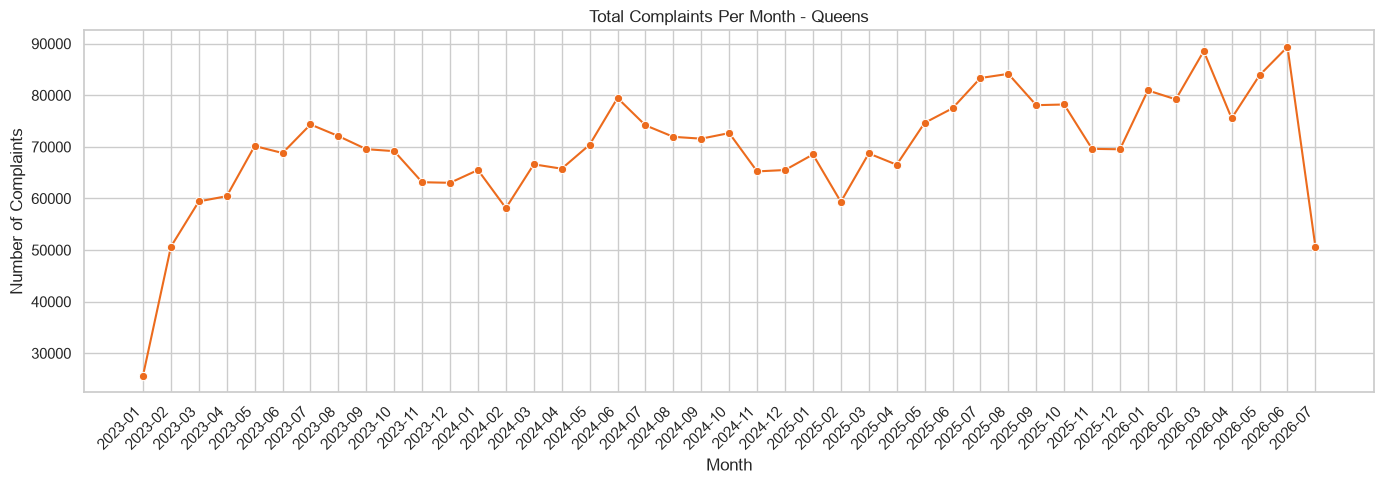

In [102]:
complaints_df['month'] = pd.to_datetime(complaints_df['created_date']).dt.to_period('M')
monthly_complaints = complaints_df['month'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.lineplot(x=monthly_complaints.index.astype(str), y=monthly_complaints.values, marker='o', color=complaints_colors[2])
plt.title('Total Complaints Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

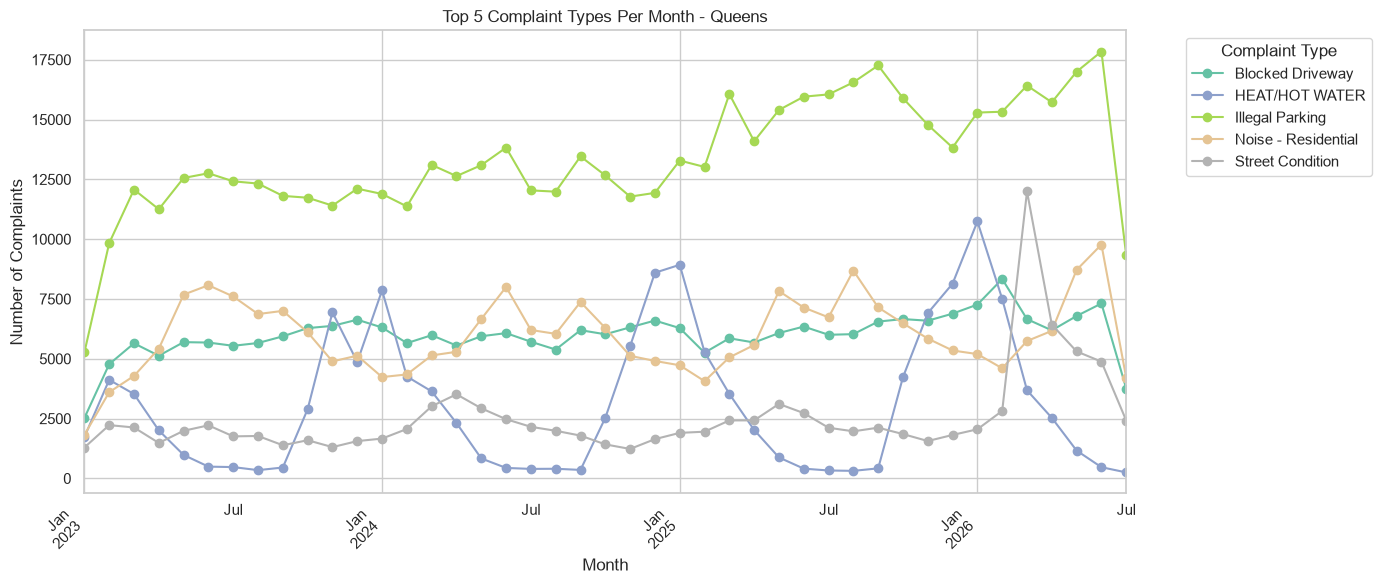

In [103]:
top5 = complaints_df['complaint_type'].value_counts().head(5).index

top5_monthly = (
    complaints_df[complaints_df['complaint_type'].isin(top5)]
    .groupby(['month', 'complaint_type'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 6))
top5_monthly.plot(kind='line', marker='o', colormap='Set2', ax=plt.gca())
plt.title('Top 5 Complaint Types Per Month - Queens')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Complaint Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---